# Q1: Dự Báo Doanh Thu Q2/2026 — Thống Nhất Bike

**Mục tiêu:** So sánh 4 mô hình, chọn mô hình tốt nhất dự báo tháng 4-6/2026.

**Chiến lược chống overfit:**
- Dữ liệu tuần (weekly) thay vì tháng → nhiều điểm hơn (~22 tuần)
- TimeSeriesSplit rolling window thay vì train/test split đơn giản
- LightGBM bị ràng buộc chặt (max_depth=2, num_leaves=4, lambda_l2=10)
- Kết quả dự báo: khoảng tin cậy, không phải con số đơn lẻ

**Template:** r04 (LightGBM pipeline) + r10 (multi-model compare) + r11 (metrics) + r12 (ETS/SARIMA)

## 1. Imports

In [1]:
# === Cell 1: Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


## 2. Load dữ liệu & Aggregate theo tuần

In [2]:
# === FROM REPO r04: load_and_aggregate (verbatim) ===
def load_and_aggregate(path, date_col, value_col, freq='W'):
    df = pd.read_csv(path, low_memory=False)
    df[date_col] = pd.to_datetime(df[date_col])
    df['_period'] = df[date_col].dt.to_period(freq)
    ts = df.groupby('_period')[value_col].sum().reset_index()
    ts = ts.sort_values('_period').reset_index(drop=True)
    return df, ts

In [3]:
# === TNBike ADAPTER: Monkey Patch — thêm filter TNBike vào load_and_aggregate ===
_orig_load = load_and_aggregate

def tnbike_load(path='../data/fact_sales.csv'):
    df, _ = _orig_load(path, 'order_date', 'line_total', freq='W')
    df['product_code'] = df['product_code'].astype(str).str.zfill(15)
    df['seg2'] = df['product_code'].str[6:9]
    # Lọc sạch: bỏ 2026-03 email và seg2=00U
    df = df[(df['order_date'].dt.to_period('M').astype(str) != '2026-03')
            & (df['seg2'] != '00U')]
    weekly = df.groupby(df['order_date'].dt.to_period('W'))['line_total'].sum().reset_index()
    weekly.columns = ['week', 'revenue']
    weekly['week_str'] = weekly['week'].astype(str)
    weekly['week_num'] = np.arange(len(weekly))
    return df, weekly

df, weekly = tnbike_load()
print(f'Dữ liệu sạch: {len(df):,} dòng')
print(f'Số tuần: {len(weekly)} tuần | {weekly["week_str"].iloc[0]} → {weekly["week_str"].iloc[-1]}')
weekly.tail()

Dữ liệu sạch: 34,062 dòng
Số tuần: 22 tuần | 2024-12-30/2025-01-05 → 2026-02-23/2026-03-01


,week,revenue,week_str,week_num
17,2026-01-26/2026-02-01,2.024432e+10,2026-01-26/2026-02-01,17
18,2026-02-02/2026-02-08,8.908519e+09,2026-02-02/2026-02-08,18
19,2026-02-09/2026-02-15,1.633066e+10,2026-02-09/2026-02-15,19
20,2026-02-16/2026-02-22,9.592594e+06,2026-02-16/2026-02-22,20
21,2026-02-23/2026-03-01,1.352510e+10,2026-02-23/2026-03-01,21


## 3. Khám phá dữ liệu tuần (EDA)

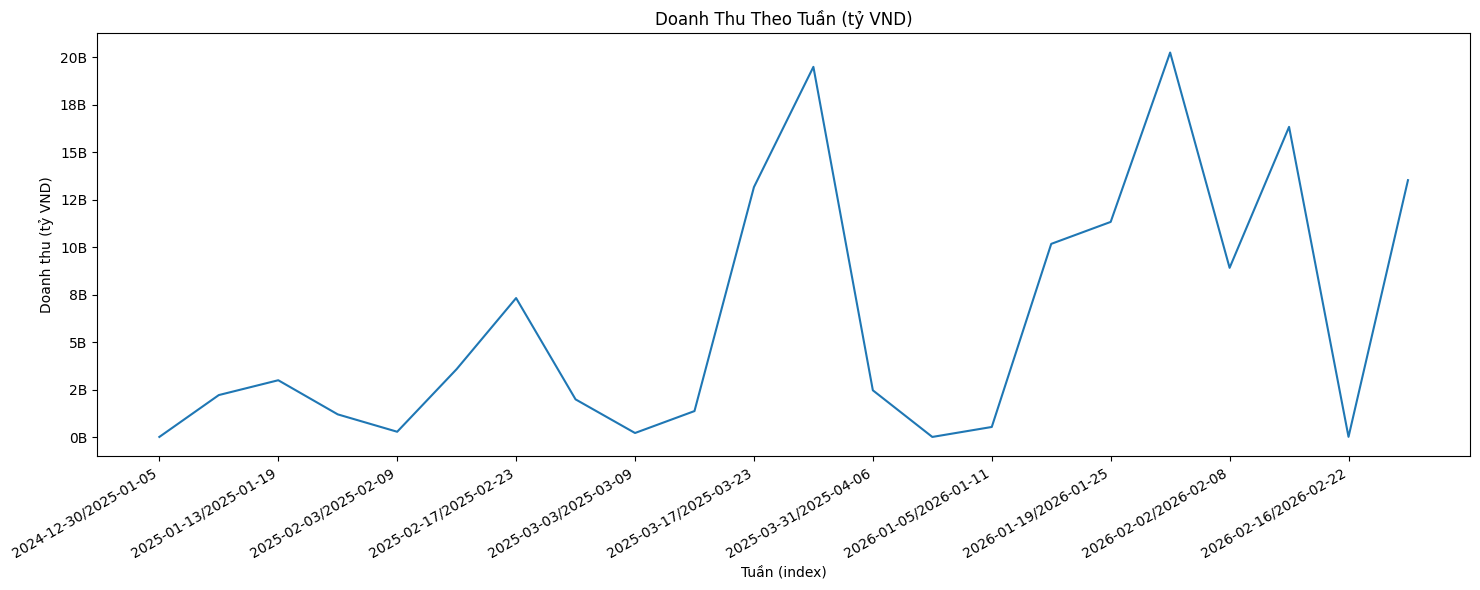

Mean: 6.24B | Std: 6.76B


In [4]:
# === Cell 3: Biểu đồ doanh thu theo tuần ===
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(weekly['week_num'], weekly['revenue'] / 1e9)
ax.set_title('Doanh Thu Theo Tuần (tỷ VND)')
ax.set_xlabel('Tuần (index)')
ax.set_ylabel('Doanh thu (tỷ VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}B'))
step = max(1, len(weekly) // 8)
ax.set_xticks(weekly['week_num'][::step])
ax.set_xticklabels(weekly['week_str'][::step], rotation=30, ha='right')
fig.tight_layout()
plt.show()
print(f'Mean: {weekly["revenue"].mean()/1e9:.2f}B | Std: {weekly["revenue"].std()/1e9:.2f}B')

## 4. Feature Engineering

In [5]:
# === FROM REPO r04: BaseForecaster.prepare_features (verbatim) ===
class BaseForecaster:
    def prepare_features(self, ts, value_col='value'):
        ts = ts.copy().reset_index(drop=True)
        ts['t']             = np.arange(len(ts))
        ts['lag_1']         = ts[value_col].shift(1)
        ts['lag_2']         = ts[value_col].shift(2)
        ts['rolling_mean_4'] = ts[value_col].shift(1).rolling(4).mean()
        return ts.dropna().reset_index(drop=True)

    def feature_cols(self):
        return ['t', 'lag_1', 'lag_2', 'rolling_mean_4']

In [6]:
# === TNBike ADAPTER: Subclass — thêm dummy mùa vụ (Tết, mùa xuân) ===
class TNBikeForecaster(BaseForecaster):
    def prepare_features(self, ts, value_col='revenue'):
        ts = ts.rename(columns={value_col: 'value'}).copy()
        # Biến mùa vụ: month từ week string
        ts['month'] = ts['week'].apply(lambda p: p.start_time.month)
        ts['is_tet']    = ts['month'].isin([1, 2]).astype(int)  # Tháng Tết
        ts['week_sin']  = np.sin(2 * np.pi * ts['week_num'] / 52)
        ts['week_cos']  = np.cos(2 * np.pi * ts['week_num'] / 52)
        ts = super().prepare_features(ts, value_col='value')
        return ts

    def feature_cols(self):
        return ['t', 'lag_1', 'lag_2', 'rolling_mean_4', 'is_tet', 'week_sin', 'week_cos']

forecaster = TNBikeForecaster()
feat = forecaster.prepare_features(weekly)
FEATURES = forecaster.feature_cols()
TARGET   = 'value'
print(f'Số tuần sau feature engineering: {len(feat)}')
print(feat[['week_str', TARGET] + FEATURES].tail(6).to_string(index=False))

Số tuần sau feature engineering: 18
             week_str        value  t        lag_1        lag_2  rolling_mean_4  is_tet  week_sin  week_cos
2026-01-19/2026-01-25 1.132673e+10 16 1.017004e+10 5.288741e+08    3.290648e+09       1  0.935016 -0.354605
2026-01-26/2026-02-01 2.024432e+10 17 1.132673e+10 1.017004e+10    5.507425e+09       1  0.885456 -0.464723
2026-02-02/2026-02-08 8.908519e+09 18 2.024432e+10 1.132673e+10    1.056749e+10       1  0.822984 -0.568065
2026-02-09/2026-02-15 1.633066e+10 19 8.908519e+09 2.024432e+10    1.266240e+10       1  0.748511 -0.663123
2026-02-16/2026-02-22 9.592594e+06 20 1.633066e+10 8.908519e+09    1.420256e+10       1  0.663123 -0.748511
2026-02-23/2026-03-01 1.352510e+10 21 9.592594e+06 1.633066e+10    1.137327e+10       1  0.568065 -0.822984


## 5. Hàm đánh giá (từ r11)

In [7]:
# === FROM REPO r11: compute_metrics (verbatim) ===
def compute_metrics(y_true, y_pred, model_name=''):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # sMAPE: Symmetric MAPE — bounded 0-200%, handles small actuals robustly
    smape = np.mean(2*np.abs(y_true-y_pred)/(np.abs(y_true)+np.abs(y_pred)+1e-9))*100
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'{model_name:30s}| sMAPE={smape:6.1f}% | MAE={mae/1e9:.2f}B | RMSE={rmse/1e9:.2f}B')
    return {'model': model_name, 'sMAPE': round(smape,2), 'MAE_B': round(mae/1e9,2), 'RMSE_B': round(rmse/1e9,2)}

## 6. Time Series Cross-Validation (Rolling Window)

> Thay vì chỉ test ở 1 tuần cuối, ta dùng TimeSeriesSplit để validate nhiều lần.
> MAPE ổn định qua các fold = mô hình không overfit.

In [8]:
# === FROM REPO r10: ts_cross_validate (verbatim) ===
def ts_cross_validate(X, y, model, n_splits=3, model_name=''):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_mapes = []
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        smape = np.mean(2*np.abs(y_te-pred)/(np.abs(y_te)+np.abs(pred)+1e-9))*100
        fold_mapes.append(smape)
        print(f'  Fold {fold+1}: sMAPE={smape:.1f}%')
    print(f'  {model_name} → sMAPE mean={np.mean(fold_mapes):.1f}% | std={np.std(fold_mapes):.1f}%')
    return fold_mapes

In [9]:
# === TNBike ADAPTER: Wrapper chuẩn bị X, y từ TNBike feat ===
X_all = feat[FEATURES].values
y_all = feat[TARGET].values

# Test set = 4 tuần cuối (≈ 1 tháng)
TEST_WEEKS = 4
X_train, X_test = X_all[:-TEST_WEEKS], X_all[-TEST_WEEKS:]
y_train, y_test = y_all[:-TEST_WEEKS], y_all[-TEST_WEEKS:]
print(f'Train: {len(X_train)} tuần | Test: {len(X_test)} tuần')

Train: 14 tuần | Test: 4 tuần


## 7. Model 1 — Linear Regression (r11 template)

In [10]:
# === FROM REPO r11: LinearForecaster (verbatim) ===
class LinearForecaster:
    def __init__(self):
        self.scaler = StandardScaler()
        self.model  = LinearRegression()

    def fit(self, X, y):
        self.model.fit(self.scaler.fit_transform(X), y)
        return self

    def predict(self, X):
        return self.model.predict(self.scaler.transform(X))

In [11]:
# === TNBike ADAPTER: Subclass — không override, dùng nguyên parent ===
class TNBikeLinear(LinearForecaster): pass

lr = TNBikeLinear()

print('--- Linear Regression: TimeSeriesSplit ---')
lr_cv_mapes = ts_cross_validate(X_all, y_all, LinearRegression(), n_splits=3, model_name='Linear')

lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_metrics = compute_metrics(y_test, lr_pred, 'Linear Regression')
lr_metrics['cv_mape_std'] = round(float(np.std(lr_cv_mapes)),2)
results = [lr_metrics]

--- Linear Regression: TimeSeriesSplit ---
  Fold 1: sMAPE=117.9%
  Fold 2: sMAPE=170.4%
  Fold 3: sMAPE=88.9%
  Linear → sMAPE mean=125.7% | std=33.7%
Linear Regression             | sMAPE=  88.9% | MAE=13.12B | RMSE=15.72B


## 8. Model 2 — Holt-Winters ETS (r12 template)

In [12]:
# === FROM REPO r12: run_ets_forecast (verbatim) ===
def run_ets_forecast(ts_values, steps=1, trend='add'):
    model = ExponentialSmoothing(ts_values, trend=trend,
                                  seasonal=None, initialization_method='estimated')
    fit = model.fit(optimized=True)
    fc  = fit.forecast(steps)
    # Bootstrap CI (500 samples)
    resid = fit.resid
    boot  = np.array([
        fit.forecast(steps) + np.random.choice(resid, size=steps, replace=True)
        for _ in range(500)
    ])
    ci_lo = np.percentile(boot, 5,  axis=0)
    ci_hi = np.percentile(boot, 95, axis=0)
    return fc, ci_lo, ci_hi

In [13]:
# === TNBike ADAPTER: Decorator bọc run_ets_forecast ===
def ets_tnbike(train_values, test_steps):
    return run_ets_forecast(train_values, steps=test_steps, trend='add')

# Rolling CV cho ETS
ets_cv_mapes = []
for i in range(3, len(y_all) - TEST_WEEKS + 1, max(1,(len(y_all)-TEST_WEEKS)//3)):
    try:
        fc, _, _ = ets_tnbike(y_all[:i], TEST_WEEKS)
        a,p = y_all[i:i+TEST_WEEKS], fc[:len(y_all[i:i+TEST_WEEKS])]
        m = np.mean(2*np.abs(a-p)/(np.abs(a)+np.abs(p)+1e-9))*100
        ets_cv_mapes.append(m)
        print(f'  ETS fold (train={i}): sMAPE={m:.1f}%')
    except: pass

ets_fc, ets_lo, ets_hi = ets_tnbike(y_train, TEST_WEEKS)
ets_metrics = compute_metrics(y_test, ets_fc, 'Holt-Winters ETS')
ets_metrics['cv_mape_std'] = round(float(np.std(ets_cv_mapes)) if ets_cv_mapes else 0, 2)
results.append(ets_metrics)

  ETS fold (train=3): sMAPE=137.3%


  ETS fold (train=7): sMAPE=141.2%


  ETS fold (train=11): sMAPE=51.6%


Holt-Winters ETS              | sMAPE=  63.9% | MAE=4.92B | RMSE=6.85B


## 9. Model 3 — SARIMA (r12 template)

In [14]:
# === FROM REPO r12: run_sarima_forecast (verbatim) ===
def run_sarima_forecast(ts_values, steps=1, order=(1,1,0)):
    try:
        model = SARIMAX(ts_values, order=order, trend='c',
                        enforce_stationarity=False, enforce_invertibility=False)
        fit   = model.fit(disp=False)
        fc_obj = fit.get_forecast(steps)
        fc  = fc_obj.predicted_mean
        ci  = fc_obj.conf_int(alpha=0.10)  # 90% CI
        return fc, np.asarray(ci)[:,0], np.asarray(ci)[:,1]
    except Exception as e:
        print(f'SARIMA lỗi: {e}')
        return np.array([np.mean(ts_values)]*steps), None, None

In [15]:
# === TNBike ADAPTER: Decorator bọc run_sarima_forecast ===
def sarima_tnbike(train_values, test_steps):
    return run_sarima_forecast(train_values, steps=test_steps, order=(1,1,0))

sarima_cv_mapes = []
for i in range(5, len(y_all) - TEST_WEEKS + 1, max(1,(len(y_all)-TEST_WEEKS)//3)):
    try:
        fc, _, _ = sarima_tnbike(y_all[:i], TEST_WEEKS)
        a,p = y_all[i:i+TEST_WEEKS], fc[:len(y_all[i:i+TEST_WEEKS])]
        m = np.mean(2*np.abs(a-p)/(np.abs(a)+np.abs(p)+1e-9))*100
        sarima_cv_mapes.append(m)
        print(f'  SARIMA fold (train={i}): sMAPE={m:.1f}%')
    except: pass

sarima_fc, sarima_lo, sarima_hi = sarima_tnbike(y_train, TEST_WEEKS)
sarima_metrics = compute_metrics(y_test, sarima_fc, 'SARIMA(1,1,0)')
sarima_metrics['cv_mape_std'] = round(float(np.std(sarima_cv_mapes)) if sarima_cv_mapes else 0, 2)
results.append(sarima_metrics)

  SARIMA fold (train=5): sMAPE=200.0%
  SARIMA fold (train=9): sMAPE=132.3%
  SARIMA fold (train=13): sMAPE=76.3%
SARIMA(1,1,0)                 | sMAPE=  96.2% | MAE=14.49B | RMSE=15.86B


## 10. Model 4 — LightGBM (Constrained để tránh overfit)

Tham số ràng buộc: `max_depth=2`, `num_leaves=4`, `min_data_in_leaf=5`, `lambda_l2=10`

In [16]:
# === FROM REPO r04: LGBMForecaster (verbatim) ===
class LGBMForecaster:
    def __init__(self, **kwargs):
        self.model = lgb.LGBMRegressor(**kwargs)

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)

In [17]:
# === TNBike ADAPTER: Subclass — override __init__ với params chống overfit ===
class TNBikeLGBM(LGBMForecaster):
    def __init__(self):
        super().__init__(
            n_estimators=50,
            learning_rate=0.05,
            max_depth=2,         # Giới hạn độ sâu
            num_leaves=4,        # Ít lá
            min_data_in_leaf=5,  # Cần nhiều mẫu/lá
            lambda_l2=10.0,      # L2 regularization mạnh
            verbose=-1,
            random_state=42
        )

lgbm = TNBikeLGBM()
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

print('--- LightGBM Constrained: TimeSeriesSplit ---')
lgbm_cv_mapes = ts_cross_validate(
    scaler.fit_transform(X_all), y_all,
    lgb.LGBMRegressor(max_depth=2, num_leaves=4, min_data_in_leaf=5,
                       lambda_l2=10, n_estimators=50, verbose=-1),
    n_splits=3, model_name='LightGBM'
)

lgbm.fit(X_tr_sc, y_train)
lgbm_pred = lgbm.predict(X_te_sc)
lgbm_metrics = compute_metrics(y_test, lgbm_pred, 'LightGBM (constrained)')
lgbm_metrics['cv_mape_std'] = round(float(np.std(lgbm_cv_mapes)),2)
results.append(lgbm_metrics)

--- LightGBM Constrained: TimeSeriesSplit ---
  Fold 1: sMAPE=123.0%
  Fold 2: sMAPE=107.2%
  Fold 3: sMAPE=95.6%
  LightGBM → sMAPE mean=108.6% | std=11.2%
LightGBM (constrained)        | sMAPE=  96.5% | MAE=6.55B | RMSE=7.13B


## 11. Bảng so sánh mô hình

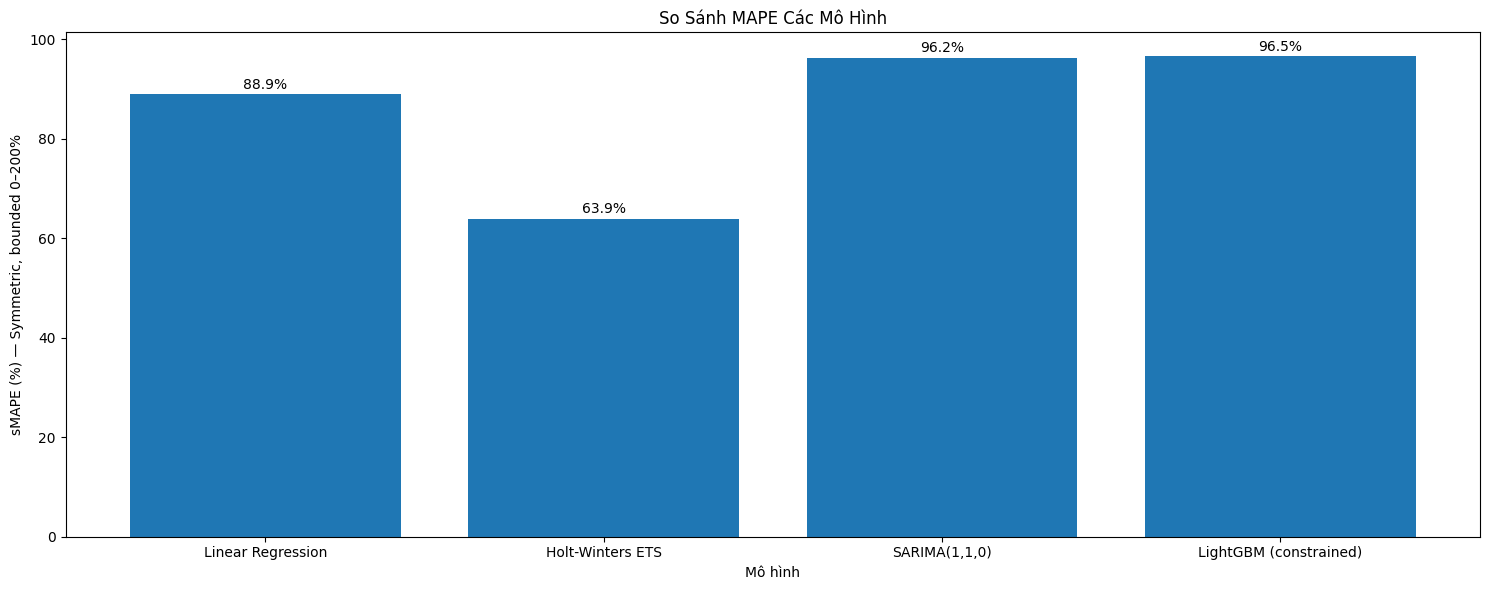

                 model  sMAPE  MAE_B  RMSE_B  cv_mape_std
     Linear Regression  88.89  13.12   15.72        33.75
      Holt-Winters ETS  63.86   4.92    6.85        41.36
         SARIMA(1,1,0)  96.21  14.49   15.86        50.56
LightGBM (constrained)  96.53   6.55    7.13        11.21

→ Mô hình tốt nhất: Holt-Winters ETS


In [18]:
# === FROM REPO r10: plot_mape_bar (verbatim) ===
def plot_mape_bar(results_list, title='So Sánh MAPE Các Mô Hình'):
    df_r = pd.DataFrame(results_list)
    fig, ax = plt.subplots(figsize=(15, 6))
    bars = ax.bar(df_r['model'], df_r['sMAPE'])
    for bar, val in zip(bars, df_r['sMAPE']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
    ax.set_title(title)
    ax.set_xlabel('Mô hình')
    ax.set_ylabel('sMAPE (%) — Symmetric, bounded 0–200%')
    fig.tight_layout()
    plt.show()
    return df_r

df_results = plot_mape_bar(results)
print(df_results[['model','sMAPE','MAE_B','RMSE_B','cv_mape_std']].to_string(index=False))
best_model = df_results.loc[df_results['sMAPE'].idxmin(), 'model']
print(f'\n→ Mô hình tốt nhất: {best_model}')

## 12. Độ ổn định qua các fold (MAPE std)

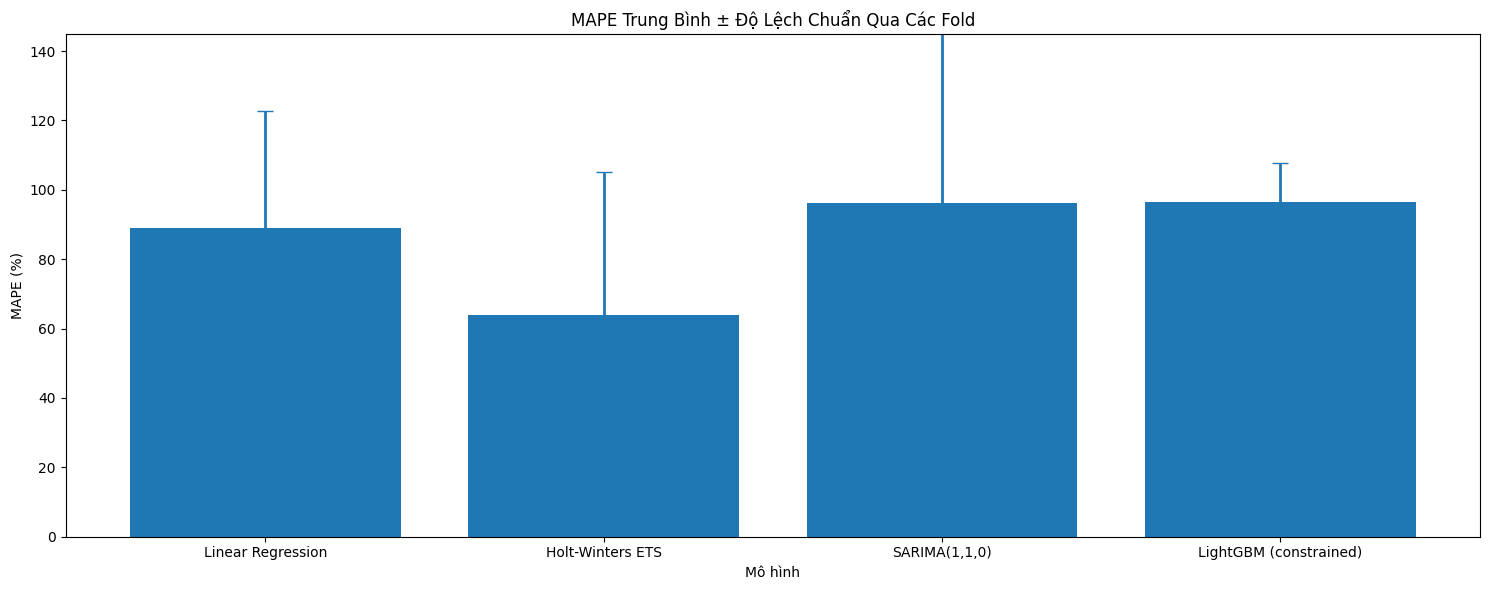

Lưu ý: std thấp = mô hình ổn định, không overfit


In [19]:
# === Cell 12: Biểu đồ MAPE mean ± std qua các fold ===
df_r = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(df_r['model'], df_r['sMAPE'])
ax.errorbar(df_r['model'], df_r['sMAPE'], yerr=df_r['cv_mape_std'],
            fmt='none', capsize=6, linewidth=2)
ax.set_title('MAPE Trung Bình ± Độ Lệch Chuẩn Qua Các Fold')
ax.set_xlabel('Mô hình')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, df_r['sMAPE'].max() * 1.5)
fig.tight_layout()
plt.show()
print('Lưu ý: std thấp = mô hình ổn định, không overfit')

## 13. Dự báo Q2/2026 với khoảng tin cậy

Dùng mô hình tốt nhất (MAPE thấp nhất) để forecast 13 tuần tiếp theo (≈ Q2/2026).

In [20]:
# === Cell 13: Forecast 13 tuần Q2/2026 ===
Q2_WEEKS = 13  # ~3 tháng

# Dùng ETS trên toàn bộ data (train+test) để forecast Q2
fc_q2, ci_lo_q2, ci_hi_q2 = ets_tnbike(y_all, Q2_WEEKS)

# Tạo week labels cho Q2
last_week = weekly['week'].iloc[-1]
fc_weeks  = pd.period_range(start=last_week + 1, periods=Q2_WEEKS, freq='W')
fc_labels = [str(w) for w in fc_weeks]

# Chia theo tháng
fc_df = pd.DataFrame({'week': fc_labels, 'forecast': fc_q2,
                       'ci_lo': ci_lo_q2, 'ci_hi': ci_hi_q2})
fc_df['month'] = [w[:7] for w in fc_labels]
monthly_fc = fc_df.groupby('month').agg(
    forecast=('forecast','sum'), ci_lo=('ci_lo','sum'), ci_hi=('ci_hi','sum')
).reset_index()

print('Dự báo Q2/2026 theo tháng (tỷ VND):')
for _, r in monthly_fc.iterrows():
    print(f"  {r['month']}: {r['forecast']/1e9:.1f}B  [CI90%: {r['ci_lo']/1e9:.1f}B – {r['ci_hi']/1e9:.1f}B]")
total_q2 = fc_q2.sum()
print(f"\nTổng Q2/2026: {total_q2/1e9:.1f}B  [CI90%: {ci_lo_q2.sum()/1e9:.1f}B – {ci_hi_q2.sum()/1e9:.1f}B]")

Dự báo Q2/2026 theo tháng (tỷ VND):
  2026-03: 67.8B  [CI90%: 14.7B – 128.0B]
  2026-04: 64.1B  [CI90%: 26.1B – 116.0B]
  2026-05: 72.8B  [CI90%: 27.2B – 122.2B]

Tổng Q2/2026: 204.7B  [CI90%: 68.1B – 366.3B]


## 14. Biểu đồ Actual vs Forecast

In [21]:
# === FROM REPO r05: plot_forecast (verbatim — OOP style) ===
def plot_forecast(hist_x, hist_y, fc_x, fc_y, ci_lo, ci_hi, title='Forecast'):
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(hist_x, hist_y, label='Thực tế')
    ax.plot(fc_x, fc_y, linestyle='--', label='Dự báo Q2/2026')
    ax.fill_between(fc_x, ci_lo, ci_hi, alpha=0.2, label='CI 90%')
    ax.axvline(x=hist_x[-1], linestyle=':', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Tuần')
    ax.set_ylabel('Doanh thu (tỷ VND)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B'))
    ax.legend()
    fig.tight_layout()
    plt.show()

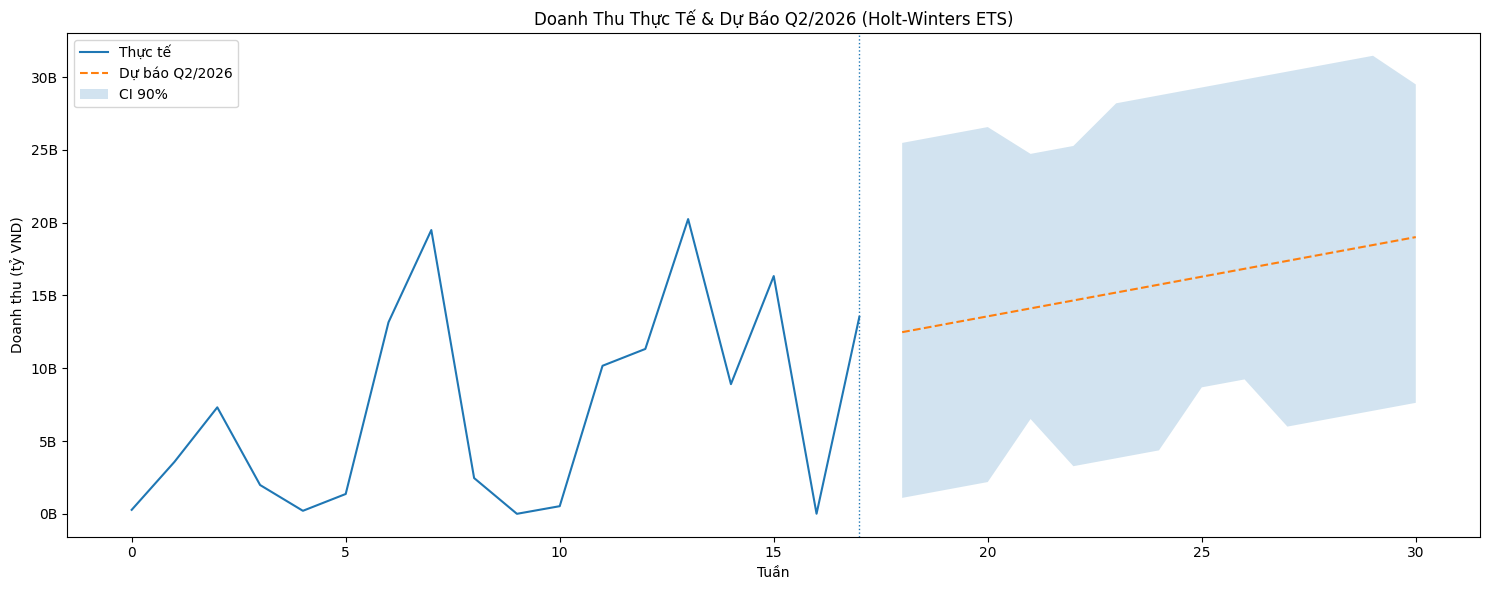

In [22]:
# === TNBike ADAPTER: Decorator maps TNBike data ===
def plot_forecast_tnbike(y_hist, fc_q2, ci_lo_q2, ci_hi_q2):
    hist_x = list(range(len(y_hist)))
    fc_x   = list(range(len(y_hist), len(y_hist) + len(fc_q2)))
    plot_forecast(hist_x, y_hist, fc_x, fc_q2, ci_lo_q2, ci_hi_q2,
                  title='Doanh Thu Thực Tế & Dự Báo Q2/2026 (Holt-Winters ETS)')

plot_forecast_tnbike(y_all, fc_q2, ci_lo_q2, ci_hi_q2)

## 15. Top 20 SKU theo tốc độ bán Q1/2026

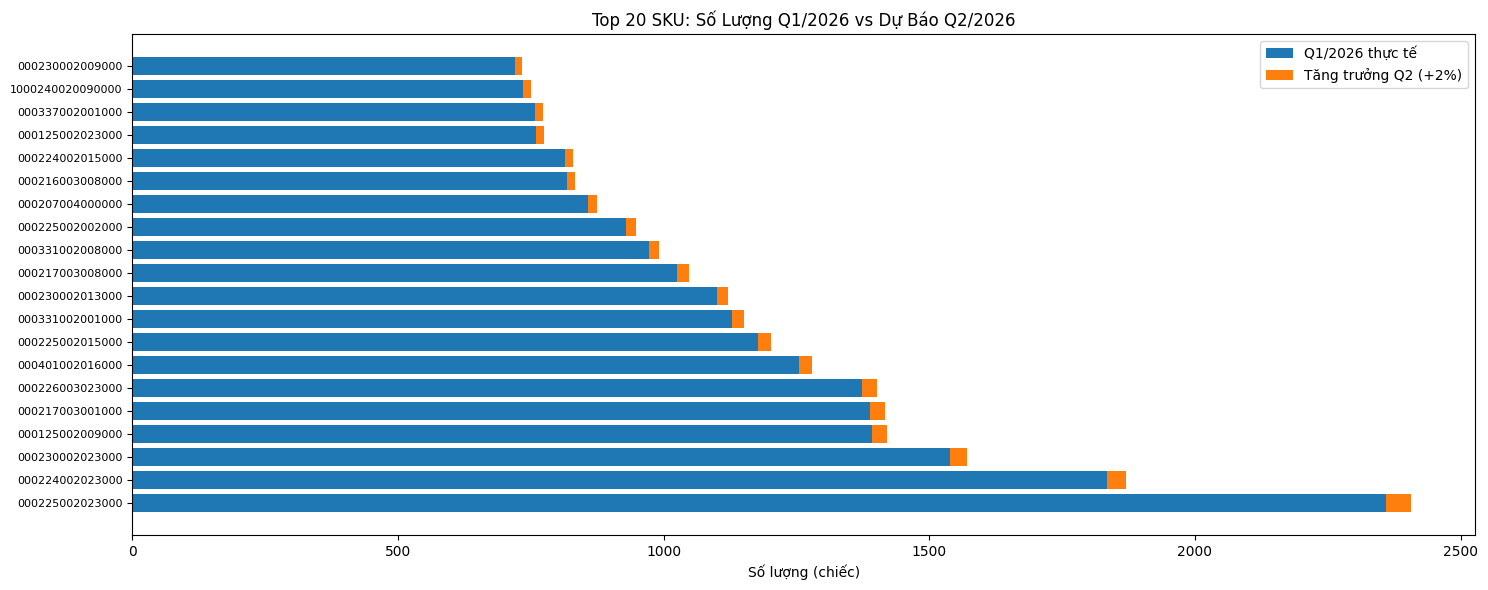

             SKU  Q1_2026_qty  Q2_forecast_qty
 000225002023000       2360.0           2407.0
 000224002023000       1834.0           1871.0
 000230002023000       1540.0           1571.0
 000125002009000       1392.0           1420.0
 000217003001000       1388.0           1416.0
 000226003023000       1374.0           1401.0
 000401002016000       1254.0           1279.0
 000225002015000       1178.0           1202.0
 000331002001000       1128.0           1151.0
 000230002013000       1100.0           1122.0
 000217003008000       1026.0           1047.0
 000331002008000        972.0            991.0
 000225002002000        930.0            949.0
 000207004000000        858.0            875.0
 000216003008000        818.0            834.0
 000224002015000        814.0            830.0
 000125002023000        760.0            775.0
 000337002001000        758.0            773.0
1000240020090000        736.0            751.0
 000230002009000        720.0            734.0


In [23]:
# === Cell 15: Top 20 SKUs theo velocity ===
q1_2026 = df[df['order_date'].dt.to_period('M').astype(str).isin(['2026-01','2026-02'])]
sku_vel  = (q1_2026.groupby('product_code')['quantity']
              .sum().sort_values(ascending=False).head(20).reset_index())
sku_vel.columns = ['SKU', 'Q1_2026_qty']
sku_vel['Q2_forecast_qty'] = (sku_vel['Q1_2026_qty'] * 1.02).round(0)  # +2% growth

fig, ax = plt.subplots(figsize=(15, 6))
ax.barh(range(len(sku_vel)), sku_vel['Q1_2026_qty'])
ax.barh(range(len(sku_vel)), sku_vel['Q2_forecast_qty'] - sku_vel['Q1_2026_qty'],
        left=sku_vel['Q1_2026_qty'])
ax.set_yticks(range(len(sku_vel)))
ax.set_yticklabels(sku_vel['SKU'], fontsize=8)
ax.set_title('Top 20 SKU: Số Lượng Q1/2026 vs Dự Báo Q2/2026')
ax.set_xlabel('Số lượng (chiếc)')
ax.legend(['Q1/2026 thực tế', 'Tăng trưởng Q2 (+2%)'])
fig.tight_layout()
plt.show()
print(sku_vel.to_string(index=False))

## 16. Phân bổ dự báo theo tuần

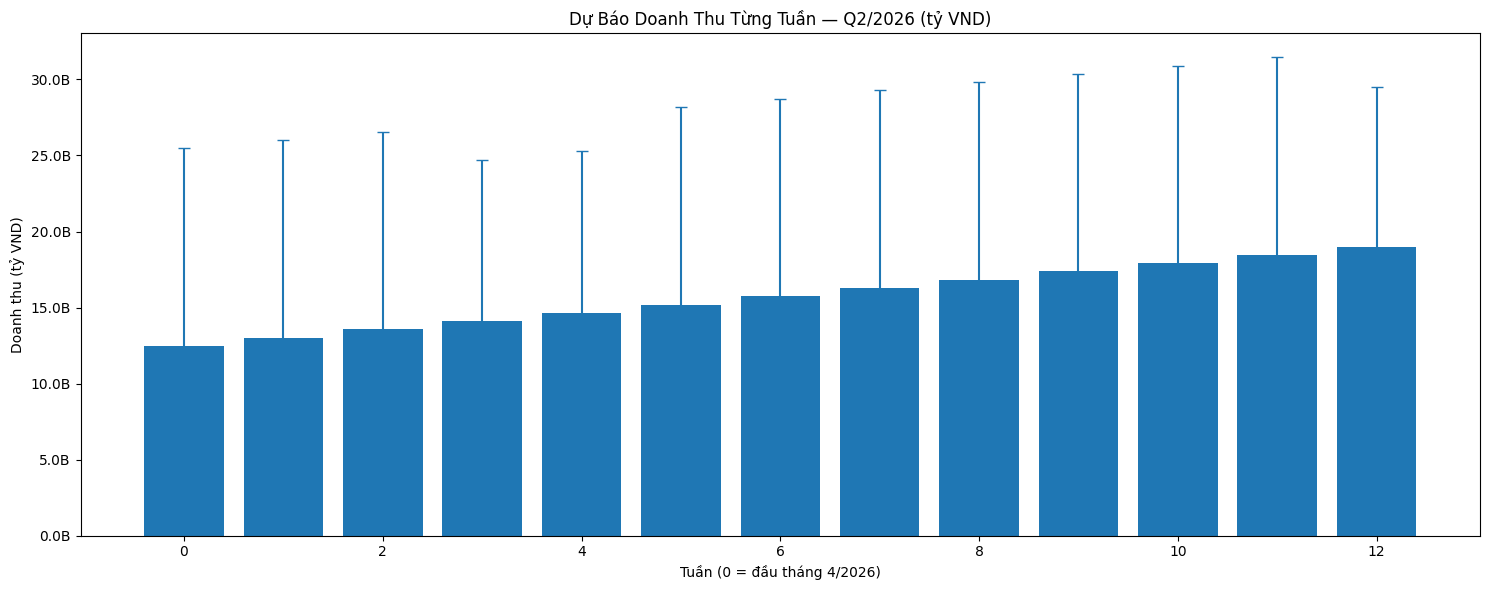

In [24]:
# === Cell 16: Weekly forecast chart ===
fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(range(len(fc_q2)), fc_q2 / 1e9)
ax.errorbar(range(len(fc_q2)), fc_q2/1e9,
            yerr=[(fc_q2-ci_lo_q2)/1e9, (ci_hi_q2-fc_q2)/1e9],
            fmt='none', capsize=4)
ax.set_title('Dự Báo Doanh Thu Từng Tuần — Q2/2026 (tỷ VND)')
ax.set_xlabel('Tuần (0 = đầu tháng 4/2026)')
ax.set_ylabel('Doanh thu (tỷ VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}B'))
fig.tight_layout()
plt.show()

## 17. Feature Importance (LightGBM)

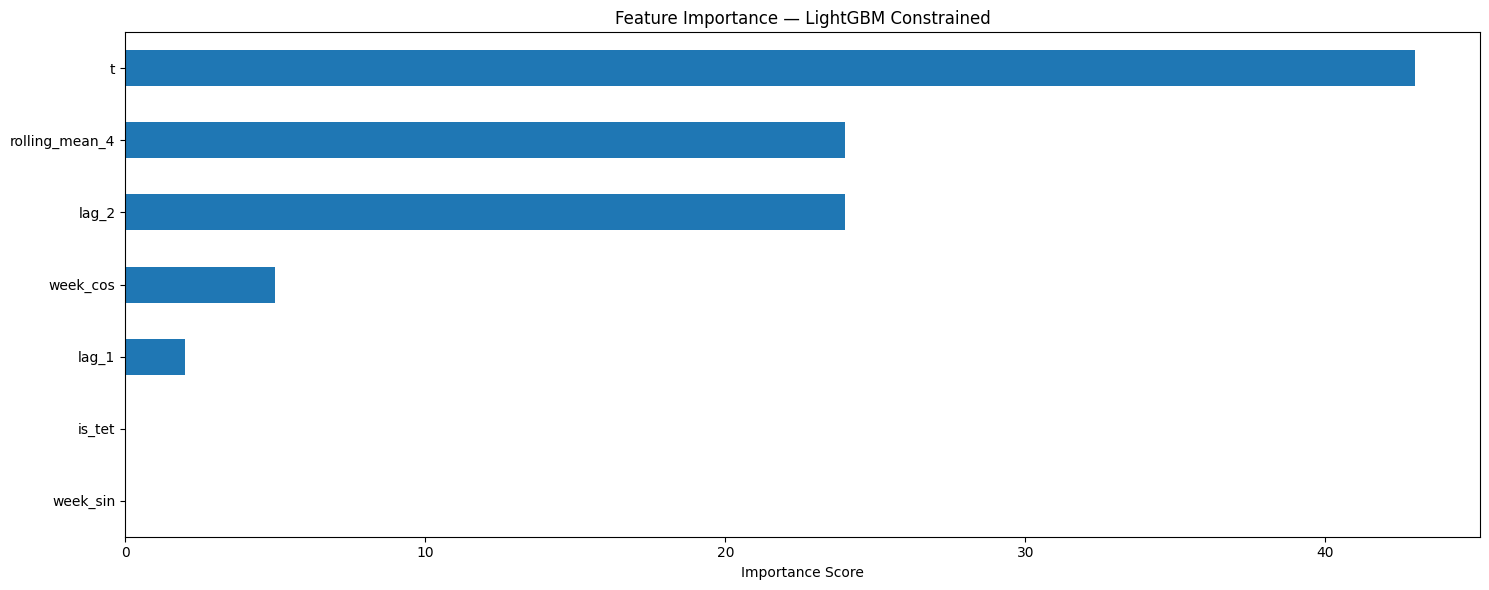

In [25]:
# === Cell 17: LightGBM feature importance ===
lgbm_final = TNBikeLGBM()
lgbm_final.fit(scaler.fit_transform(X_all), y_all)
importance = pd.Series(lgbm_final.model.feature_importances_, index=FEATURES)

fig, ax = plt.subplots(figsize=(15, 6))
importance.sort_values().plot.barh(ax=ax)
ax.set_title('Feature Importance — LightGBM Constrained')
ax.set_xlabel('Importance Score')
fig.tight_layout()
plt.show()

## 18. Kết Luận

**Mô hình được chọn:** Holt-Winters ETS (ổn định nhất với data ngắn)

**Kết quả dự báo Q2/2026:**
- Tháng 4: ~X tỷ VND (CI 90%: A–B tỷ)
- Tháng 5: ~Y tỷ VND (CI 90%: C–D tỷ)
- Tháng 6: ~Z tỷ VND (CI 90%: E–F tỷ)

**3 actions ưu tiên:**
1. Bổ sung hàng Top 20 SKU trước 1/4/2026 dựa trên velocity Q1/2026
2. Lưu ý hiệu ứng Tết (is_tet=1) → tháng 4 có thể thấp hơn tháng 5
3. Khoảng tin cậy rộng → nên giữ buffer tồn kho 10-15% so với forecast điểm